# 模型输出可视化评估

这个 notebook 用于检查训练后模型在单个样本上的输出，包括 input image、confidence map、GT/predicted position、GT/predicted size/shape、segmentation。默认入口是前面新增的天文 2D 模型；如果要看原始 CELLECT 3D 模型，把 `MODEL_KIND` 改成 `"cellect3d"`，并设置 3D TIFF 与 checkpoint 路径。


In [12]:
from pathlib import Path

# Choose "astro2d" for the astronomy model, or "cellect3d" for original CELLECT 3D UNet output inspection.
MODEL_KIND = "astro2d"  # "astro2d" or "cellect3d"

# ---------- Astro 2D settings ----------
ASTRO_ROOT = Path("./output/hsc_test/").expanduser()
ASTRO_CHECKPOINT = Path("./output/astro_hsc_i_en/best.pt")
BANDS = ["HSC-I"] # "HSC-G", "HSC-R", 
OVERLAY_BAND = "HSC-I"  # "first", band name such as "HSC-I", or integer index such as 0
SAMPLE_INDEX = -1
FITS_HDU = 0
SOURCE_FILTER = "nchild0"
TARGETS_DIR = ASTRO_ROOT / "targets"
SHAPE_SOURCE = "sdss"       # "kron", "sdss", or "circular_kron"
ELLIPSE_SIGMA = 3.0
CORE_RADIUS = 2
CONF_THRESHOLD = 0.0
CONFIDENCE_SCORE = "cellect"
NMS_RADIUS = 1
CENTER_TOLERANCE_ARCSEC = 0.5
PIXEL_SCALE_ARCSEC = 0.168
MATCH_RADIUS = CENTER_TOLERANCE_ARCSEC / PIXEL_SCALE_ARCSEC

# ---------- CELLECT 3D settings ----------
CELLECT_U_CHECKPOINT = Path("./output/U-ext+-xstr0-149.0-2.8969.pth")
CELLECT_FRAME1 = Path("./extradata/mskcc-confocal/mskcc_confocal_s2/images/mskcc_confocal_s2_t220.tif")
CELLECT_FRAME2 = Path("./extradata/mskcc-confocal/mskcc_confocal_s2/images/mskcc_confocal_s2_t221.tif")
Z_INDEX = 20

DEVICE = "cuda"  # change to "cpu" if needed


In [13]:
import math
import sys
from typing import Dict, List, Tuple

import numpy as np
try:
    import pandas as pd
except Exception:
    pd = None
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

device = torch.device(DEVICE if (DEVICE == "cpu" or torch.cuda.is_available()) else "cpu")
print("device:", device)

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

def robust_gray(image2d):
    image2d = np.asarray(image2d, dtype=np.float32)
    finite = np.isfinite(image2d)
    if not finite.any():
        return np.zeros_like(image2d, dtype=np.float32)
    lo, hi = np.nanpercentile(image2d[finite], [1, 99])
    if hi <= lo:
        return np.zeros_like(image2d, dtype=np.float32)
    return np.clip((image2d - lo) / (hi - lo), 0, 1)

def select_display_band_gray(chw, bands, display_band="first"):
    arr = to_numpy(chw).astype(np.float32)
    if arr.ndim == 2:
        return robust_gray(arr), "single band", 0
    if arr.shape[0] == 0:
        raise ValueError("Input image has no bands to display")

    if display_band is None or display_band == "first":
        index = 0
    elif isinstance(display_band, int):
        index = display_band
    elif isinstance(display_band, str):
        if display_band in bands:
            index = list(bands).index(display_band)
        else:
            suffix_matches = [i for i, name in enumerate(bands) if str(name).endswith("-" + display_band) or str(name).endswith(display_band)]
            if len(suffix_matches) == 1:
                index = suffix_matches[0]
            else:
                raise ValueError(f"OVERLAY_BAND={display_band!r} is not in BANDS={list(bands)!r}")
    else:
        raise TypeError("OVERLAY_BAND must be 'first', a band name, or an integer index")

    if index < 0 or index >= arr.shape[0]:
        raise IndexError(f"OVERLAY_BAND index {index} is out of range for {arr.shape[0]} input bands")
    label = str(bands[index]) if index < len(bands) else f"band {index}"
    return robust_gray(arr[index]), label, index

def make_first_band_gray(chw):
    gray, _label, _index = select_display_band_gray(chw, BANDS, "first")
    return gray

def make_display_image(chw):
    arr = to_numpy(chw).astype(np.float32)
    if arr.ndim == 2:
        return robust_gray(arr)
    if arr.shape[0] == 1:
        return robust_gray(arr[0])
    bands = [robust_gray(arr[min(i, arr.shape[0] - 1)]) for i in range(3)]
    return np.stack(bands[::-1], axis=-1)  # RGB = I,R,G when using HSC-G/R/I

def display_xy(xy, height):
    xy = np.asarray(xy, dtype=np.float32).copy()
    if xy.size:
        xy[:, 1] = float(height - 1) - xy[:, 1]
    return xy

def display_shape(shape):
    shape = np.asarray(shape, dtype=np.float32).copy()
    if shape.ndim == 2 and shape.shape[1] > 2:
        shape[:, 2] = -shape[:, 2]
    return shape

def sample_map_at_xy(map_chw, xy):
    m = to_numpy(map_chw)
    xy = np.asarray(xy, dtype=np.float32)
    if xy.size == 0:
        return np.zeros((0, m.shape[0]), dtype=np.float32)
    h, w = m.shape[-2:]
    x = np.clip(np.rint(xy[:, 0]).astype(int), 0, w - 1)
    y = np.clip(np.rint(xy[:, 1]).astype(int), 0, h - 1)
    return m[:, y, x].T

def greedy_match(pred_xy, gt_xy, radius):
    pred_xy = np.asarray(pred_xy, dtype=np.float32)
    gt_xy = np.asarray(gt_xy, dtype=np.float32)
    if len(pred_xy) == 0 or len(gt_xy) == 0:
        return []
    dist = np.sqrt(((pred_xy[:, None, :] - gt_xy[None, :, :]) ** 2).sum(axis=2))
    pairs = []
    for pi in range(dist.shape[0]):
        gi = int(np.argmin(dist[pi]))
        if dist[pi, gi] <= radius:
            pairs.append((float(dist[pi, gi]), pi, gi))
    pairs.sort()
    used_p, used_g, out = set(), set(), []
    for d, pi, gi in pairs:
        if pi in used_p or gi in used_g:
            continue
        used_p.add(pi); used_g.add(gi); out.append((pi, gi, d))
    return out

def draw_ellipses(ax, xy, shape, edgecolor, label=None, max_items=200):
    xy = np.asarray(xy, dtype=np.float32)
    shape = np.asarray(shape, dtype=np.float32)
    for i, (cx, cy) in enumerate(xy[:max_items]):
        if shape.shape[0] <= i or shape.shape[1] < 2:
            continue
        a = max(float(shape[i, 0]), 0.5)
        b = max(float(shape[i, 1]), 0.5)
        theta = float(shape[i, 2]) if shape.shape[1] > 2 and np.isfinite(shape[i, 2]) else 0.0
        ax.add_patch(Ellipse((cx, cy), width=2*a, height=2*b, angle=np.degrees(theta), fill=False, lw=1.0, ec=edgecolor, alpha=0.75, label=label if i == 0 else None))

def masked_positive(mask):
    mask = np.asarray(mask)
    return np.ma.masked_where(mask <= 0, mask)


device: cuda


## Astro 2D: 加载样本、checkpoint，并前向推理


In [14]:
if MODEL_KIND == "astro2d":
    from astro_cellect2d import AstroMatchNet2D, AstroUNet2D
    from astro_train_eval import (
        AstroCutoutDataset,
        build_cellect_style_segmentation,
        collate_cutouts,
        detect_centers,
        discover_cutout_records,
    )

    records = discover_cutout_records(ASTRO_ROOT, bands=BANDS)
    print(f"records: {len(records)}")
    rec = records[SAMPLE_INDEX]
    print("sample:", rec)

    dataset = AstroCutoutDataset(
        [rec],
        fits_hdu=FITS_HDU,
        confidence_levels=5,
        ellipse_sigma=ELLIPSE_SIGMA,
        core_radius=CORE_RADIUS,
        shape_source=SHAPE_SOURCE,
        source_filter=SOURCE_FILTER,
        targets_dir=TARGETS_DIR if TARGETS_DIR.exists() else None,
        augment=False,
    )
    item = dataset[0]
    batch = collate_cutouts([item])
    image = batch["image"].to(device=device, dtype=torch.float32)

    ckpt = torch.load(ASTRO_CHECKPOINT.expanduser(), map_location=device)
    ckpt_args = ckpt.get("args", {}) if isinstance(ckpt, dict) else {}
    if isinstance(ckpt, dict) and "center_radius_px" in ckpt:
        MATCH_RADIUS = float(ckpt["center_radius_px"])
    embedding_dim = int(ckpt_args.get("embedding_dim", 64))
    base_channels = int(ckpt_args.get("base_channels", 32))
    model = AstroUNet2D(
        in_channels=len(BANDS),
        seg_classes=3,
        confidence_levels=5,
        embedding_dim=embedding_dim,
        base_channels=base_channels,
        shape_channels=3,
    ).to(device)
    state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    print(ckpt.keys() if isinstance(ckpt, dict) else "checkpoint is not a dict")
    print(state.keys() if isinstance(state, dict) else "model state is not a dict")
    # Replace 'backbone.' prefix if it exists in the checkpoint keys but not in the model state dict keys
    if isinstance(state, dict):
        model_keys = set(model.state_dict().keys())
        state_keys = set(state.keys())
        if not model_keys.issubset(state_keys) and all(("backbone." + k) in state_keys for k in model_keys):
            state = {k[len("backbone."):]: v for k, v in state.items() if k.startswith("backbone.")}
    model.load_state_dict(state)
    ex_net = AstroMatchNet2D(feature_dim=embedding_dim).to(device)
    en_net = AstroMatchNet2D(feature_dim=embedding_dim).to(device)
    loaded_ex = isinstance(ckpt, dict) and "EX" in ckpt
    loaded_en = isinstance(ckpt, dict) and "EN" in ckpt
    if loaded_ex:
        ex_net.load_state_dict(ckpt["EX"])
    if loaded_en:
        en_net.load_state_dict(ckpt["EN"])
    model.eval(); ex_net.eval(); en_net.eval()

    with torch.no_grad():
        outputs = model(image)

    pred_xy = detect_centers(
        outputs,
        threshold=CONF_THRESHOLD,
        nms_radius=NMS_RADIUS,
        confidence_score=CONFIDENCE_SCORE,
    )[0]
    cellect_seg = build_cellect_style_segmentation(outputs, [pred_xy], ellipse_sigma=ELLIPSE_SIGMA)[0]
    pred_seg_raw = cellect_seg["seg"]
    pred_seg_mask_raw = cellect_seg["seg_mask"]

    gt_xy = batch["centers"][0].numpy().astype(np.float32)
    matches = greedy_match(pred_xy, gt_xy, MATCH_RADIUS)
    matched_pred = {pi for pi, _gi, _dist in matches}
    matched_gt = {gi for _pi, gi, _dist in matches}
    tp = len(matches)
    fp = len(pred_xy) - tp
    fn = len(gt_xy) - tp
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    print("image:", tuple(image.shape), "GT centers:", len(gt_xy), "pred centers:", len(pred_xy), "matches:", len(matches))
    print(f"GT match radius: {MATCH_RADIUS:.3f} px = {CENTER_TOLERANCE_ARCSEC} arcsec / {PIXEL_SCALE_ARCSEC} arcsec-per-pixel")
    print(f"detection: TP={tp}, FP={fp}, FN={fn}, precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}")
    print("seg foreground pixels:", int((pred_seg_raw > 0).sum()), "seg_mask pixels:", int((pred_seg_mask_raw > 0).sum()), "instances:", int(pred_seg_mask_raw.max()))
    print("EX loaded:", loaded_ex, "EN loaded:", loaded_en)
    print("outputs:", {k: tuple(v.shape) for k, v in outputs.items()})
else:
    print("Skip Astro 2D cells because MODEL_KIND != 'astro2d'.")


records: 9
sample: CutoutRecord(name='zangetsu_r02_c02_x27366_y7477', image_paths=('output/hsc_test/cutouts/zangetsu_r02_c02_x27366_y7477/HSC-I/denoised.fits',), meas_path='output/hsc_test/reference_catalogs/zangetsu_r02_c02_x27366_y7477_meas.fits', x0=27366, y0=7477, band_meas_paths=())
dict_keys(['model', 'EX', 'EN', 'model_variant', 'epoch', 'args', 'loss_weights', 'center_radius_px', 'val', 'detection'])
odict_keys(['backbone.conv_c1_1.weight', 'backbone.conv_c1_2.weight', 'backbone.lrelu_conv_c1.1.weight', 'backbone.conv_c2.weight', 'backbone.conv_c2s1.weight', 'backbone.conv_c2s2.weight', 'backbone.norm_lrelu_conv_c2.2.weight', 'backbone.conv_c3.weight', 'backbone.conv_c3s1.weight', 'backbone.conv_c3s2.weight', 'backbone.norm_lrelu_conv_c3.2.weight', 'backbone.conv_c4.weight', 'backbone.conv_c4s1.weight', 'backbone.conv_c4s2.weight', 'backbone.norm_lrelu_conv_c4.2.weight', 'backbone.up_l0.3.weight', 'backbone.conv_l0.weight', 'backbone.conv_norm_lrelu_l1.0.weight', 'backbone.conv

In [15]:
if MODEL_KIND == "astro2d":
    gt_shape_at_gt = sample_map_at_xy(batch["shape"][0], gt_xy)
    pred_shape_at_gt = sample_map_at_xy(outputs["shape"][0], gt_xy)
    pred_shape_at_pred = sample_map_at_xy(outputs["shape"][0], pred_xy)

    gt_rows = [
        {"gt_index": i, "gt_x": gt_xy[i, 0], "gt_y": gt_xy[i, 1], "matched": i in matched_gt,
         "gt_major": gt_shape_at_gt[i, 0], "gt_minor": gt_shape_at_gt[i, 1], "gt_angle": gt_shape_at_gt[i, 2]}
        for i in range(len(gt_xy))
    ]
    pred_rows = [
        {"pred_index": i, "pred_x": pred_xy[i, 0], "pred_y": pred_xy[i, 1], "matched": i in matched_pred,
         "pred_major": pred_shape_at_pred[i, 0], "pred_minor": pred_shape_at_pred[i, 1], "pred_angle": pred_shape_at_pred[i, 2]}
        for i in range(len(pred_xy))
    ]
    rows = []
    for pi, gi, dist in matches:
        rows.append({
            "gt_x": gt_xy[gi, 0], "gt_y": gt_xy[gi, 1],
            "pred_x": pred_xy[pi, 0], "pred_y": pred_xy[pi, 1],
            "dist_px": dist,
            "gt_major": gt_shape_at_gt[gi, 0], "gt_minor": gt_shape_at_gt[gi, 1], "gt_angle": gt_shape_at_gt[gi, 2],
            "pred_major_at_pred": pred_shape_at_pred[pi, 0], "pred_minor_at_pred": pred_shape_at_pred[pi, 1], "pred_angle_at_pred": pred_shape_at_pred[pi, 2],
            "pred_major_at_gt": pred_shape_at_gt[gi, 0], "pred_minor_at_gt": pred_shape_at_gt[gi, 1], "pred_angle_at_gt": pred_shape_at_gt[gi, 2],
        })
    if pd is not None:
        size_df = pd.DataFrame(rows)
        if len(size_df):
            display(size_df.describe())
            display(size_df.head(30))
        else:
            print("No matched centers within MATCH_RADIUS; only unmatched overlays will be shown.")
        print("GT centers")
        display(pd.DataFrame(gt_rows).head(30))
        print("Pred centers")
        display(pd.DataFrame(pred_rows).head(30))
    elif rows:
        print("pandas is not available; showing first 10 matched size rows as dictionaries.")
        for row in rows[:10]:
            print(row)
        print("GT centers first 10:")
        for row in gt_rows[:10]:
            print(row)
        print("Pred centers first 10:")
        for row in pred_rows[:10]:
            print(row)
    else:
        print("No matched centers within MATCH_RADIUS; only unmatched overlays will be shown.")
        print("GT centers first 10:")
        for row in gt_rows[:10]:
            print(row)
        print("Pred centers first 10:")
        for row in pred_rows[:10]:
            print(row)


,gt_x,gt_y,pred_x,pred_y,dist_px,gt_major,gt_minor,gt_angle,pred_major_at_pred,pred_minor_at_pred,pred_angle_at_pred,pred_major_at_gt,pred_minor_at_gt,pred_angle_at_gt
count,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,272.491028,261.490753,272.502777,261.516663,0.574464,2.557014,1.917639,-0.125114,2.500469,1.977018,-0.038725,2.502068,1.977072,-0.043949
std,152.089676,151.862640,152.049438,151.764557,0.465626,0.706403,0.375956,0.956386,0.361078,0.215357,0.131524,0.365526,0.222882,0.131065
min,1.621094,1.385254,2.000000,1.000000,0.033207,1.000000,1.000000,-1.559555,1.620695,1.471218,-0.421268,1.620695,1.353464,-0.421268
25%,138.974609,122.199341,139.500000,122.000000,0.273842,2.095995,1.706251,-1.010969,2.205884,1.833243,-0.128117,2.205884,1.825226,-0.132671
50%,282.083984,282.296875,282.000000,282.000000,0.448030,2.407916,1.916179,-0.210706,2.473842,1.966785,-0.043272,2.471875,1.966785,-0.052059
75%,406.272949,386.356323,406.500000,385.750000,0.726574,2.820906,2.115793,0.745616,2.760931,2.115626,0.041596,2.782566,2.115892,0.036836
max,509.394531,509.299805,509.000000,509.000000,2.871254,6.381144,3.511378,1.568341,3.408748,2.647771,0.520553,3.465158,2.703113,0.520553


,gt_x,gt_y,pred_x,pred_y,dist_px,gt_major,gt_minor,gt_angle,pred_major_at_pred,pred_minor_at_pred,pred_angle_at_pred,pred_major_at_gt,pred_minor_at_gt,pred_angle_at_gt
0,455.990234,19.031738,456.0,19.0,0.033207,2.522985,1.937049,1.359915,2.833815,2.062220,-0.111648,2.833815,2.062220,-0.111648
1,242.964844,60.979980,243.0,61.0,0.040457,2.524804,1.669273,-1.204555,2.191285,1.708135,0.107054,2.191285,1.708135,0.107054
2,458.019531,180.961426,458.0,181.0,0.043237,2.331034,1.565466,-0.499349,2.316334,1.842738,-0.096634,2.316334,1.842738,-0.096634
3,437.019531,486.054688,437.0,486.0,0.058071,2.670580,2.082205,-0.160094,2.213771,1.839649,-0.015260,2.213771,1.839649,-0.015260
4,369.042969,442.055176,369.0,442.0,0.069933,2.169437,2.015727,-0.742366,2.830232,2.162729,-0.016648,2.830232,2.162729,-0.016648
5,443.072266,382.988281,443.0,383.0,0.073210,2.976472,2.132382,-1.328652,2.170975,1.921769,-0.046540,2.170975,1.921769,-0.046540
6,340.072266,305.982910,340.0,306.0,0.074259,2.527470,2.070783,-1.403392,2.150211,1.989774,-0.064570,2.150211,1.989774,-0.064570
7,229.945312,384.057129,230.0,384.0,0.079085,4.113276,2.958094,0.253211,3.274883,2.209224,-0.038843,3.274883,2.209224,-0.038843
8,49.082031,309.030762,49.0,309.0,0.087609,1.647490,1.535033,-1.099639,2.547710,2.286433,-0.095204,2.547710,2.286433,-0.095204
9,10.912109,213.971680,11.0,214.0,0.092341,2.658378,1.931284,-1.406677,2.369119,1.885261,-0.175391,2.369119,1.885261,-0.175391


GT centers


,gt_index,gt_x,gt_y,matched,gt_major,gt_minor,gt_angle
0,0,505.763672,7.526855,True,1.781582,1.521426,-0.301861
1,1,337.746094,17.466309,True,5.187020,1.000000,0.878374
2,2,303.269531,45.240723,True,2.651652,2.372949,-0.613334
3,3,81.851562,62.296387,True,2.214918,2.005843,1.320469
4,4,178.390625,76.541992,True,2.074322,1.893765,1.082483
5,5,451.521484,81.032715,True,3.487266,1.855851,0.860658
6,6,300.751953,82.791504,True,1.856185,1.566090,1.100080
7,7,345.117188,99.616699,True,2.924647,1.945652,0.144825
8,8,413.341797,122.201660,True,2.038337,1.783818,0.354222
9,9,485.486328,130.606445,True,2.805798,2.211100,-1.431520


Pred centers


,pred_index,pred_x,pred_y,matched,pred_major,pred_minor,pred_angle
0,0,110.0,1.0,True,2.251838,1.899764,0.520553
1,1,148.0,2.0,True,2.273228,1.937169,0.152709
2,2,369.0,3.0,True,2.418373,2.009421,0.112236
3,3,132.0,4.0,False,2.208918,1.664141,0.146931
4,4,85.0,8.0,True,1.734015,1.734154,-0.128093
5,5,149.0,8.0,True,2.553384,1.857517,0.168990
6,6,201.0,8.0,True,3.082093,2.277372,0.134537
7,7,506.0,8.0,True,1.915643,1.930026,-0.059842
8,8,69.0,9.0,True,2.027180,1.924343,0.103132
9,9,452.0,9.0,False,3.256184,2.275268,-0.194073


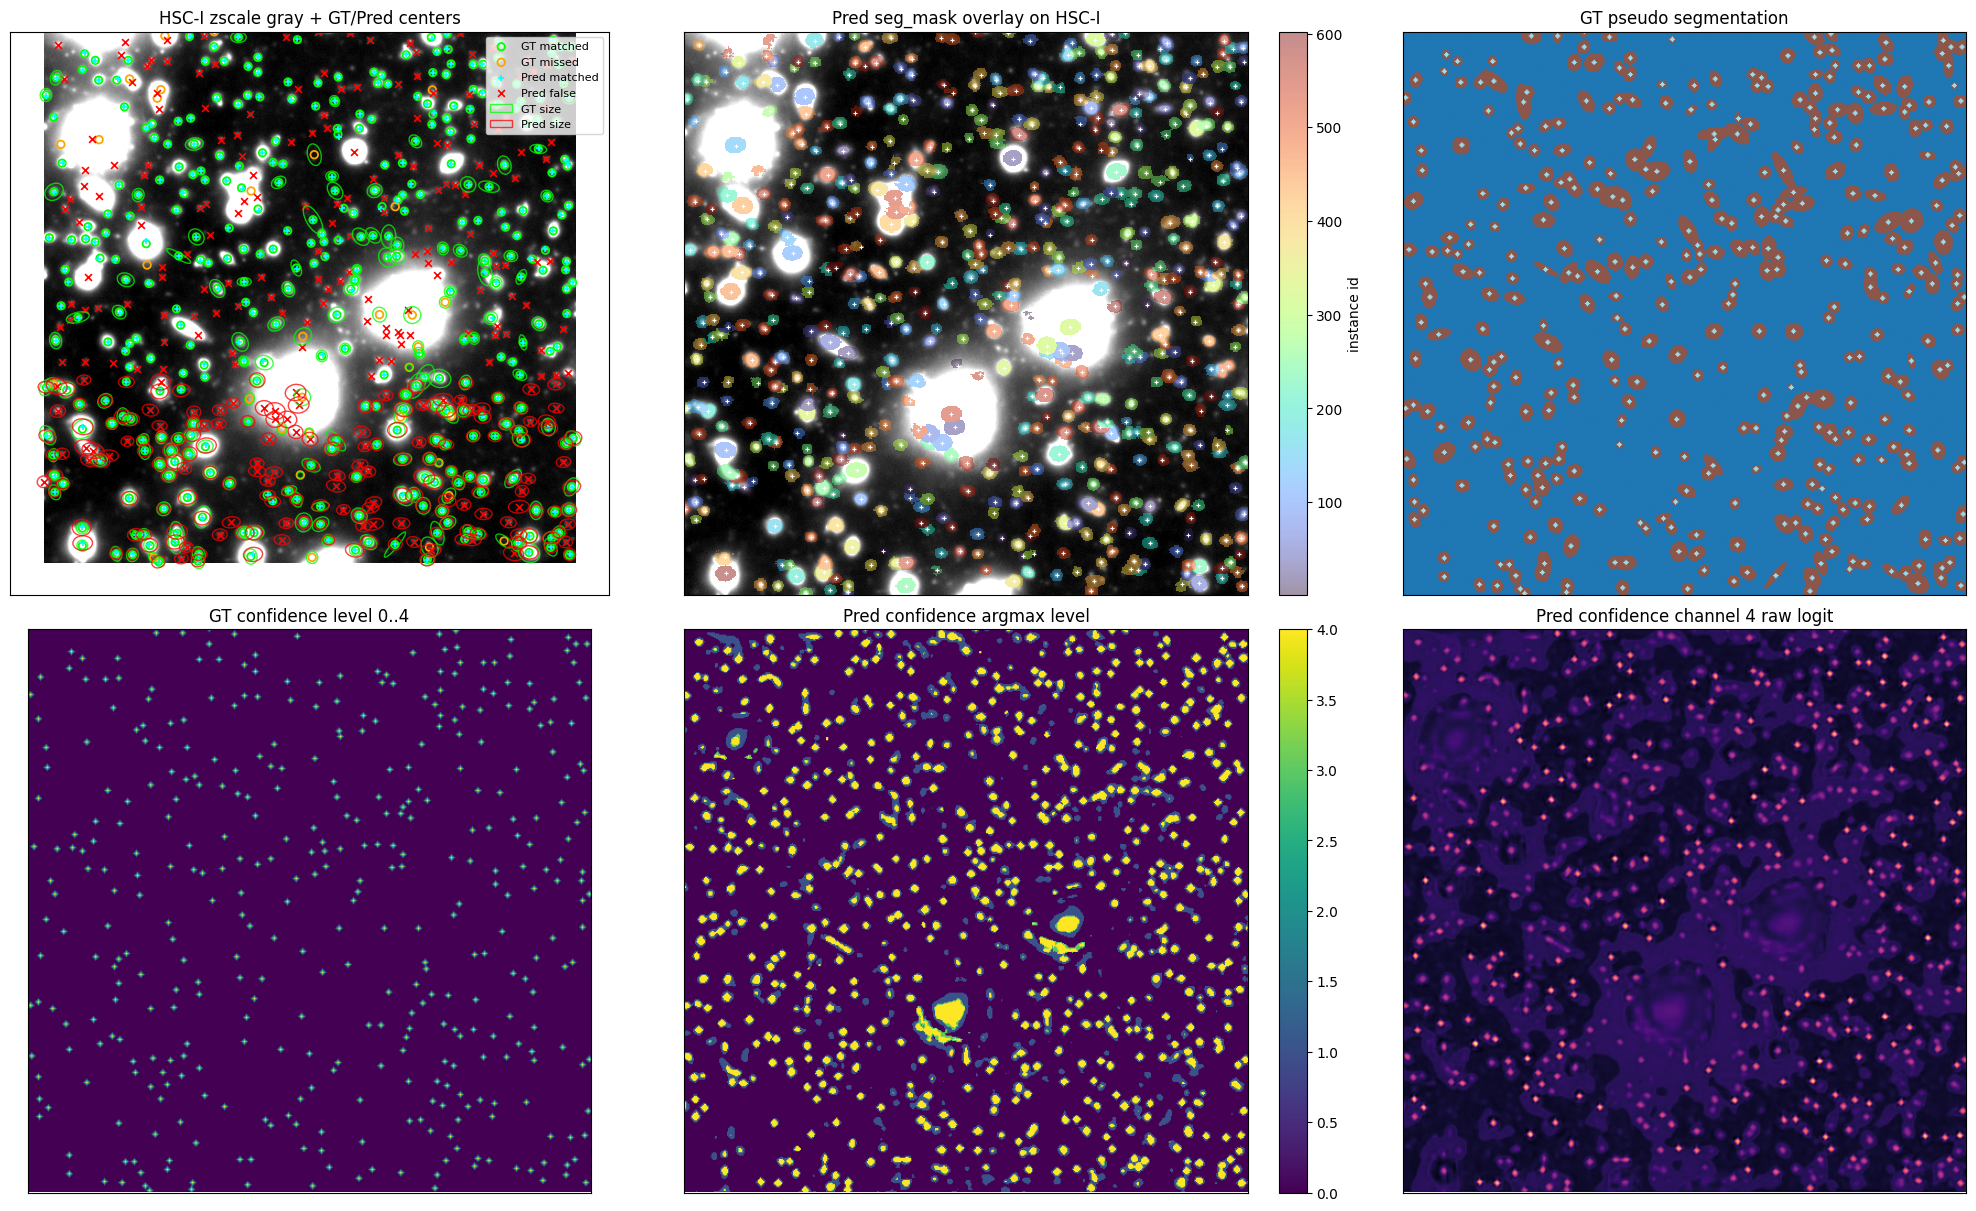

In [16]:
if MODEL_KIND == "astro2d":
    # Display arrays are vertically flipped to match FITS bottom-left visual orientation.
    # The visualization background uses OVERLAY_BAND as grayscale.
    # Center coordinates and ellipse angles are transformed by the helper functions below.
    image_gray, overlay_band_name, overlay_band_index = select_display_band_gray(batch["image"][0], BANDS, OVERLAY_BAND)
    image_gray = image_gray[::-1, :]
    h, w = image_gray.shape[:2]
    gt_xy_plot = display_xy(gt_xy, h)
    pred_xy_plot = display_xy(pred_xy, h)
    gt_shape_plot = display_shape(gt_shape_at_gt)
    pred_shape_plot = display_shape(pred_shape_at_pred)

    gt_seg = to_numpy(batch["seg"][0])[::-1, :]
    pred_seg = pred_seg_raw[::-1, :]
    pred_seg_mask = pred_seg_mask_raw[::-1, :]
    # Randomly shuffle the mask to visually distinguish adjacent instances with different colors, since the raw seg_mask may have large connected components with the same id.
    if pred_seg_mask.max() > 0:
        np.random.seed(0)
        shuffle_map = np.arange(int(pred_seg_mask.max()) + 1)
        np.random.shuffle(shuffle_map[1:])
        pred_seg_mask = shuffle_map[pred_seg_mask]
    gt_conf = to_numpy(batch["confidence"][0])[::-1, :]
    pred_conf_logits = outputs["confidence"][0].detach().cpu()
    pred_conf_top = pred_conf_logits[-1].numpy()[::-1, :]
    pred_conf_level = pred_conf_logits.argmax(dim=0).numpy()[::-1, :]

    fig, axes = plt.subplots(2, 3, figsize=(20, 12), constrained_layout=True)
    ax = axes[0, 0]
    ax.imshow(image_gray, cmap="gray", origin="upper", vmin=0, vmax=1)
    gt_matched_mask = np.array([i in matched_gt for i in range(len(gt_xy))], dtype=bool)
    pred_matched_mask = np.array([i in matched_pred for i in range(len(pred_xy))], dtype=bool)
    if len(gt_xy):
        ax.scatter(gt_xy_plot[gt_matched_mask, 0], gt_xy_plot[gt_matched_mask, 1], s=28, facecolors="none", edgecolors="lime", linewidths=1.3, label="GT matched")
        ax.scatter(gt_xy_plot[~gt_matched_mask, 0], gt_xy_plot[~gt_matched_mask, 1], s=30, facecolors="none", edgecolors="orange", linewidths=1.3, label="GT missed")
    if len(pred_xy):
        ax.scatter(pred_xy_plot[pred_matched_mask, 0], pred_xy_plot[pred_matched_mask, 1], s=22, marker="+", c="cyan", linewidths=1.2, label="Pred matched")
        ax.scatter(pred_xy_plot[~pred_matched_mask, 0], pred_xy_plot[~pred_matched_mask, 1], s=24, marker="x", c="red", linewidths=1.2, label="Pred false")
    gt_shape_plot_scaled = gt_shape_plot.copy()
    gt_shape_plot_scaled[:, :2] *= ELLIPSE_SIGMA
    pred_shape_plot_scaled = pred_shape_plot.copy()
    pred_shape_plot_scaled[:, :2] *= ELLIPSE_SIGMA
    draw_ellipses(ax, gt_xy_plot, gt_shape_plot_scaled, "lime", "GT size")
    draw_ellipses(ax, pred_xy_plot, pred_shape_plot_scaled, "red", "Pred size")
    ax.set_title(f"{overlay_band_name} zscale gray + GT/Pred centers")
    ax.legend(loc="upper right", fontsize=8)

    ax = axes[0, 1]
    ax.imshow(image_gray, cmap="gray", origin="upper", vmin=0, vmax=1)
    # Gray colormap with alpha is used for the seg_mask overlay to allow seeing the underlying image and GT seg.
    overlay = ax.imshow(masked_positive(pred_seg_mask), cmap="turbo", alpha=0.45, interpolation="nearest", origin="upper")
    if len(pred_xy):
        ax.scatter(pred_xy_plot[:, 0], pred_xy_plot[:, 1], s=10, marker="+", c="white", linewidths=0.8)
    ax.set_title(f"Pred seg_mask overlay on {overlay_band_name}")
    fig.colorbar(overlay, ax=ax, fraction=0.046, label="instance id")

    axes[0, 2].imshow(gt_seg, cmap="tab20", origin="upper", vmin=0, vmax=max(2, int(gt_seg.max())))
    axes[0, 2].set_title("GT pseudo segmentation")

    # im = axes[0, 2].imshow(pred_seg, cmap="tab20", origin="upper", vmin=0, vmax=max(2, int(pred_seg.max())))
    # axes[0, 2].set_title("Pred seg dense class map")
    # fig.colorbar(im, ax=axes[0, 2], fraction=0.046, label="class")

    # im = axes[0, 3].imshow(masked_positive(pred_seg_mask), cmap="turbo", origin="upper", interpolation="nearest")
    # axes[0, 3].set_title("Pred seg_mask instance ids")
    # fig.colorbar(im, ax=axes[0, 3], fraction=0.046, label="instance id")

    axes[1, 0].imshow(gt_conf, cmap="viridis", origin="upper", vmin=0, vmax=4)
    axes[1, 0].set_title("GT confidence level 0..4")
    im = axes[1, 1].imshow(pred_conf_level, cmap="viridis", origin="upper", vmin=0, vmax=4)
    axes[1, 1].set_title("Pred confidence argmax level")
    fig.colorbar(im, ax=axes[1, 1], fraction=0.046)

    axes[1, 2].imshow(pred_conf_top, cmap="magma", origin="upper")
    axes[1, 2].set_title("Pred confidence channel 4 raw logit")

    for ax in axes.ravel():
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()


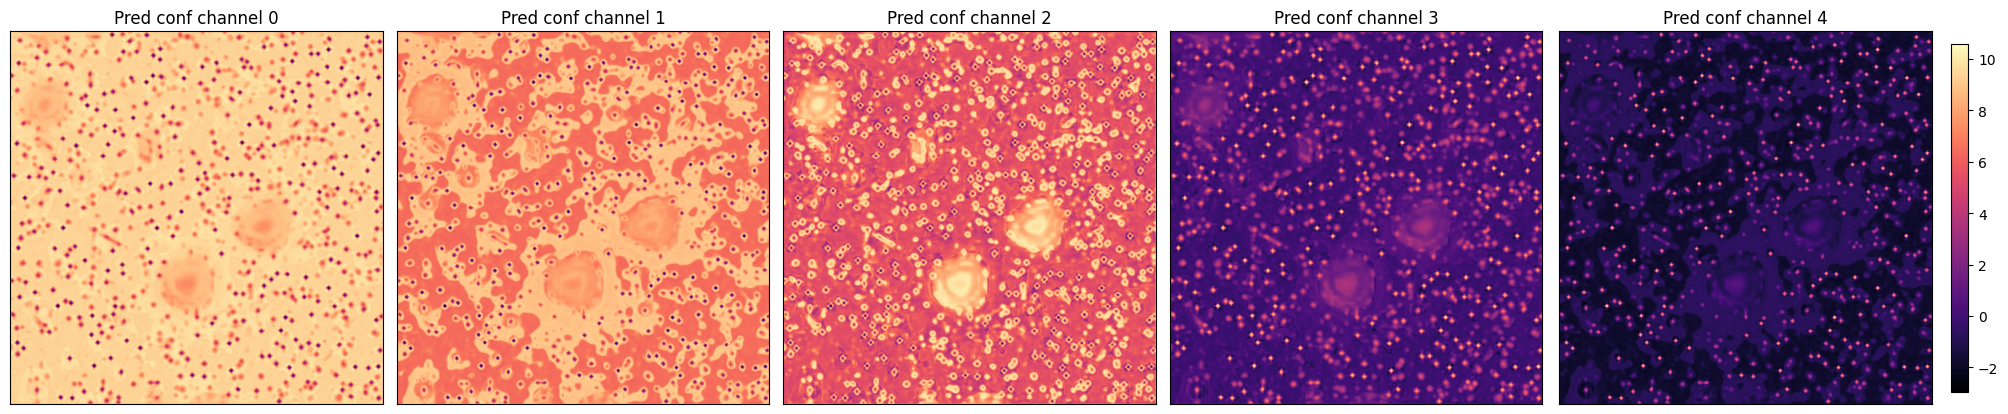

: 

In [ ]:
if MODEL_KIND == "astro2d":
    conf = outputs["confidence"][0].detach().cpu().numpy()
    fig, axes = plt.subplots(1, conf.shape[0], figsize=(4 * conf.shape[0], 4), constrained_layout=True)
    if conf.shape[0] == 1:
        axes = [axes]
    for c, ax in enumerate(axes):
        # Flip the colormap upside down
        conf_flipped = conf[c][::-1, :]
        im = ax.imshow(conf_flipped, cmap="magma", origin="upper")
        ax.set_title(f"Pred conf channel {c}")
        ax.set_xticks([]); ax.set_yticks([])
        if c == conf.shape[0] - 1:
            fig.colorbar(im, ax=ax, fraction=0.046)
    plt.show()


## CELLECT 3D: 指定 z-slice 可视化

这部分只检查 UNet 输出：confidence map、中心点、size 和 coarse segmentation。原始 CELLECT 没有直接的 GT size dense map；如果你提供 label tensor，只能显示 GT center/label，size 主要来自模型预测。


In [ ]:
if MODEL_KIND == "cellect3d":
    import tifffile
    from unetext3Dn_con7s import UNet3D
    from recoloss import run_unet_on_patches

    def PA(x):
        x = x.float()
        positive = x[x > 0]
        if positive.numel() > 0:
            af = positive.min()
            x = x.clone()
            x[x < af] = af
        x = x + 1900
        return torch.log1p(x)

    img1 = tifffile.TiffFile(str(CELLECT_FRAME1.expanduser())).asarray().transpose([1, 2, 0]).astype(np.float32)
    img2 = tifffile.TiffFile(str(CELLECT_FRAME2.expanduser())).asarray().transpose([1, 2, 0]).astype(np.float32)
    x = torch.stack([torch.from_numpy(img1), torch.from_numpy(img2)], dim=0).unsqueeze(0).to(device)
    label = torch.zeros((1, img1.shape[0], img1.shape[1], img1.shape[2]), dtype=torch.long, device=device)

    U = UNet3D(2, 6).to(device)
    U.load_state_dict(torch.load(CELLECT_U_CHECKPOINT.expanduser(), map_location=device))
    U.eval()

    with torch.no_grad():
        Uout, uo, foz, zs1, size1 = U(PA(x))
        p, f, zs, s, lb, seg_mask = run_unet_on_patches(U, PA(x), label)

    print("input:", tuple(x.shape))
    print("Uout seg logits:", tuple(Uout.shape), "confidence uo:", tuple(uo.shape), "size:", tuple(size1.shape))
    print("detected centers:", tuple(p.shape), "seg_mask:", tuple(seg_mask.shape))
else:
    print("Skip CELLECT 3D cells because MODEL_KIND != 'cellect3d'.")


In [ ]:
if MODEL_KIND == "cellect3d":
    z = int(np.clip(Z_INDEX, 0, img1.shape[2] - 1))
    p_np = p.detach().cpu().numpy() if isinstance(p, torch.Tensor) else np.zeros((0, 4))
    s_np = s.detach().cpu().numpy() if isinstance(s, torch.Tensor) else np.zeros((0,))
    in_slice = robust_gray(img1[:, :, z])
    seg_slice = seg_mask.detach().cpu().numpy()[:, :, z]
    conf_top = uo[0, 4, :, :, z].detach().cpu().numpy()
    conf_level = uo[0, :, :, :, z].argmax(dim=0).detach().cpu().numpy()
    print(f'Confidence level for z={z}: max {conf_level.max()}, min: {conf_level.min()}')
    near = np.abs(p_np[:, 3] - z) <= 1 if len(p_np) else np.array([], dtype=bool)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
    axes[0].imshow(in_slice, cmap="gray", origin="upper")
    if near.any():
        axes[0].scatter(p_np[near, 2], p_np[near, 1], s=np.clip(s_np[near] * 2, 8, 120), facecolors="none", edgecolors="red", linewidths=1.0, label="Pred centers")
        axes[0].legend(fontsize=8)
    axes[0].set_title(f"Input z={z} + predicted centers/size")
    im1 = axes[1].imshow(conf_top, cmap="magma", origin="upper", vmin=0, vmax=4)
    axes[1].set_title("Confidence channel 4 raw")
    # Only show confidence levels 0-4 since in theory confidence levels should be in this range
    # set_clim not available
    axes[1].figure.colorbar(im1, ax=axes[1], fraction=0.046)
    axes[2].imshow(conf_level, cmap="viridis", origin="upper", vmin=0, vmax=4)
    axes[2].set_title("Confidence argmax level")
    axes[3].imshow(seg_slice, cmap="gray", origin="upper")
    axes[3].set_title("Aggregated segmentation mask")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    plt.show()

    rows = [{"x": p_np[i, 1], "y": p_np[i, 2], "z": p_np[i, 3], "pred_size": s_np[i]} for i in range(len(p_np))]
    if pd is not None:
        display(pd.DataFrame(rows).head(30))
    else:
        for row in rows[:30]:
            print(row)
